# Task:2 Predicting Future Sales (Regression Model)

## Wallmart Sales Forecasting

<table align="center">
  <td>
    <a href="https://colab.research.google.com/github/BUFONJOKER/ml-ds-internship/blob/master/Task2/Task_2_wallmart_sales_forecasting_model.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"
      style="height:80px; width:auto;"/>
    </a>
  </td>
</table>

In [1]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Exploratory Data Analysis (EDA)

In [2]:
# load the dataset
df_train = pd.read_csv('wallmart_sales_forecasting.csv')
df_stores = pd.read_csv('stores.csv')
df_features = pd.read_csv('features.csv')

In [3]:
df_train.head(4)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False


In [4]:
df_stores.head(4)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863


In [5]:
df_features.head(4)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False


In [6]:
df = df_train.merge(df_stores, on=['Store'])

In [7]:
df = df_train.merge(df_features, on=['Store','Date'])

In [8]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [9]:
df.shape

(421570, 15)

In [10]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
dtype: int64

In [11]:
# Mrkdown1,2,3,4,5 has more than 50% missing values so better to remove
# and also holiday column appear twice
df.drop(['IsHoliday_x','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'],
        axis=1,inplace=True)

In [12]:
df.head(2)

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,42.31,2.572,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,38.51,2.548,211.242170,8.106,True


In [13]:
df.rename(columns={"IsHoliday_y":"IsHoliday"},inplace=True)

In [14]:
# check top few rows
df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday
0,1,1,2010-02-05,24924.50,42.31,2.572,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,38.51,2.548,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,39.93,2.514,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,46.63,2.561,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,46.50,2.625,211.350143,8.106,False


# 🏪 Walmart Weekly Sales Dataset — Column Descriptions

| **Column Name** | **Description** |
|------------------|------------------|
| **Store** | The unique **store ID** — identifies which Walmart store the record belongs to. |
| **Dept** | The **department number** within the store (e.g., Electronics, Grocery, Clothing). |
| **Date** | The **week-ending date** (YYYY-MM-DD format) for that record’s sales data. Each row represents one week of sales. |
| **Weekly_Sales** | The **total sales (in dollars)** for that store and department during that week. |
| **Temperature** | The **average temperature (°F)** in the region of the store during that week — can affect customer shopping behavior. |
| **Fuel_Price** | The **average cost of fuel (per gallon)** in the region — often used as an economic indicator. |
| **CPI** | **Consumer Price Index** — measures inflation; helps track changes in the cost of living over time. |
| **Unemployment** | The **unemployment rate (%)** in the store’s region during that week — reflects local economic conditions. |
| **IsHoliday** | A **Boolean flag (True/False)** indicating whether that week includes a major U.S. holiday (e.g., Thanksgiving, Christmas, Super Bowl). |


In [15]:
# change date column to date time
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

In [17]:
df

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,42.31,2.572,211.096358,8.106,False,2010,2,5,5
1,1,1,2010-02-12,46039.49,38.51,2.548,211.242170,8.106,True,2010,2,6,12
2,1,1,2010-02-19,41595.55,39.93,2.514,211.289143,8.106,False,2010,2,7,19
3,1,1,2010-02-26,19403.54,46.63,2.561,211.319643,8.106,False,2010,2,8,26
4,1,1,2010-03-05,21827.90,46.50,2.625,211.350143,8.106,False,2010,3,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,64.88,3.997,192.013558,8.684,False,2012,9,39,28
421566,45,98,2012-10-05,628.10,64.89,3.985,192.170412,8.667,False,2012,10,40,5
421567,45,98,2012-10-12,1061.02,54.47,4.000,192.327265,8.667,False,2012,10,41,12
421568,45,98,2012-10-19,760.01,56.47,3.969,192.330854,8.667,False,2012,10,42,19


In [18]:
df['Date'].dt.dayofweek

0         4
1         4
2         4
3         4
4         4
         ..
421565    4
421566    4
421567    4
421568    4
421569    4
Name: Date, Length: 421570, dtype: int32

In [19]:
df['Date'].dt.isocalendar().week

0          5
1          6
2          7
3          8
4          9
          ..
421565    39
421566    40
421567    41
421568    42
421569    43
Name: week, Length: 421570, dtype: UInt32

In [20]:
df['Temperature'].unique()

array([42.31, 38.51, 39.93, ..., 75.87, 77.55, 74.09], shape=(3528,))

In [21]:
# check count of missing values in each columns
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
IsHoliday       0
Year            0
Month           0
Week            0
Day             0
dtype: int64

In [22]:
# quick summary of the descriptive statistics
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,171.201947,7.960289,2010.968591,6.449510,25.826762,15.673131
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,132.022667,6.891000,2010.000000,4.000000,14.0,8.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,182.318780,7.866000,2011.000000,6.000000,26.0,16.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,212.416993,8.572000,2012.000000,9.000000,38.0,23.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0,31.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,39.159276,1.863296,0.796876,3.243217,14.151887,8.753549


In [23]:
# no. of rows and columns in dataframe
df.shape

(421570, 13)

In [24]:
# name of columns
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [25]:
# data types of each column
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
Year                     int32
Month                    int32
Week                    UInt32
Day                      int32
dtype: object

In [26]:
# unique values in store column
df['Store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [27]:
df['Dept'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65])

In [28]:
df.head(10)

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,42.31,2.572,211.096358,8.106,False,2010,2,5,5
1,1,1,2010-02-12,46039.49,38.51,2.548,211.242170,8.106,True,2010,2,6,12
2,1,1,2010-02-19,41595.55,39.93,2.514,211.289143,8.106,False,2010,2,7,19
3,1,1,2010-02-26,19403.54,46.63,2.561,211.319643,8.106,False,2010,2,8,26
4,1,1,2010-03-05,21827.90,46.50,2.625,211.350143,8.106,False,2010,3,9,5
5,1,1,2010-03-12,21043.39,57.79,2.667,211.380643,8.106,False,2010,3,10,12
6,1,1,2010-03-19,22136.64,54.58,2.720,211.215635,8.106,False,2010,3,11,19
7,1,1,2010-03-26,26229.21,51.45,2.732,211.018042,8.106,False,2010,3,12,26
8,1,1,2010-04-02,57258.43,62.27,2.719,210.820450,7.808,False,2010,4,13,2
9,1,1,2010-04-09,42960.91,65.86,2.770,210.622857,7.808,False,2010,4,14,9


In [29]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,171.201947,7.960289,2010.968591,6.449510,25.826762,15.673131
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,132.022667,6.891000,2010.000000,4.000000,14.0,8.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,182.318780,7.866000,2011.000000,6.000000,26.0,16.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,212.416993,8.572000,2012.000000,9.000000,38.0,23.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0,31.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,39.159276,1.863296,0.796876,3.243217,14.151887,8.753549


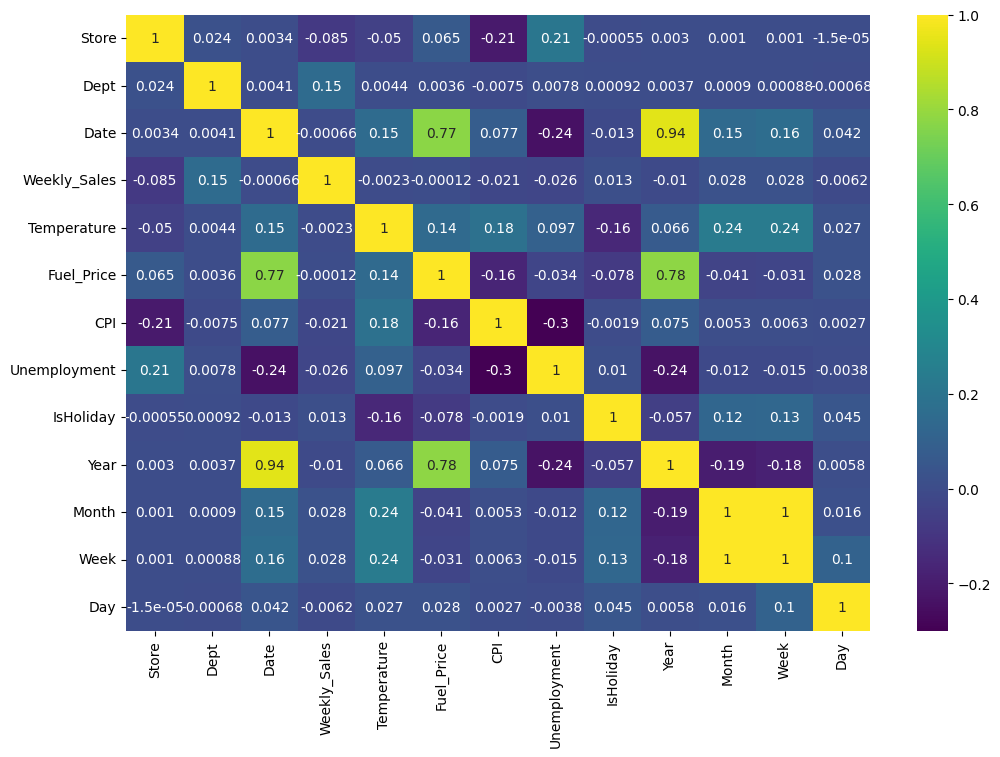

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='viridis')
plt.show()

In [31]:
df.corr()['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.000000
Dept            0.148032
Month           0.028409
Week            0.027673
IsHoliday       0.012774
Fuel_Price     -0.000120
Date           -0.000663
Temperature    -0.002312
Day            -0.006187
Year           -0.010111
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64

In [32]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [33]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
Year                     int32
Month                    int32
Week                    UInt32
Day                      int32
dtype: object

In [34]:
df['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [35]:
df[(df['Weekly_Sales']<0)]

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,Day
846,1,6,2012-08-10,-139.65,85.05,3.494,221.958433,6.908,False,2012,8,32,10
2384,1,18,2012-05-04,-1.27,75.55,3.749,221.671800,7.143,False,2012,5,18,4
6048,1,47,2010-02-19,-863.00,39.93,2.514,211.289143,8.106,False,2010,2,7,19
6049,1,47,2010-03-12,-698.00,57.79,2.667,211.380643,8.106,False,2010,3,10,12
6051,1,47,2010-10-08,-58.00,63.93,2.633,211.746754,7.838,False,2010,10,40,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,27.73,2.773,181.982317,8.992,True,2010,2,6,12
419598,45,80,2010-02-19,-0.27,31.27,2.745,182.034782,8.992,False,2010,2,7,19
419603,45,80,2010-04-16,-1.61,54.28,2.899,181.692477,8.899,False,2010,4,15,16
419614,45,80,2010-07-02,-0.27,76.61,2.815,182.318780,8.743,False,2010,7,26,2


In [36]:
df = df[df['Weekly_Sales']>0]

In [37]:
(df['Weekly_Sales']<0).sum()

np.int64(0)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
weekly_sales_store = df.groupby('Store')['Weekly_Sales'].sum()

In [40]:
top_10_stores_weekly_sales = weekly_sales_store.sort_values(ascending=False).head(10)

In [41]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [42]:
df[['Weekly_Sales',"Temperature",'IsHoliday','Month','Fuel_Price','Week','Day']].corr()

,Weekly_Sales,Temperature,IsHoliday,Month,Fuel_Price,Week,Day
Weekly_Sales,1.000000,-0.002339,0.012843,0.028401,0.000089,0.027659,-0.006265
Temperature,-0.002339,1.000000,-0.155775,0.235957,0.143700,0.236256,0.026888
IsHoliday,0.012843,-0.155775,1.000000,0.123058,-0.078155,0.127846,0.045196
Month,0.028401,0.235957,0.123058,1.000000,-0.040931,0.996000,0.016240
Fuel_Price,0.000089,0.143700,-0.078155,-0.040931,1.000000,-0.031191,0.028098
Week,0.027659,0.236256,0.127846,0.996000,-0.031191,1.000000,0.104585
Day,-0.006265,0.026888,0.045196,0.016240,0.028098,0.104585,1.000000


In [43]:
top_10_stores_weekly_sales

Store
20    3.014014e+08
4     2.995453e+08
14    2.890019e+08
13    2.865180e+08
2     2.753872e+08
10    2.716241e+08
27    2.538572e+08
6     2.237586e+08
1     2.224068e+08
39    2.074465e+08
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='Store'>

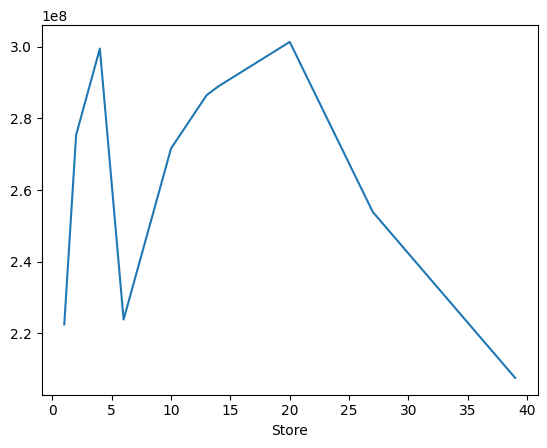

In [44]:
sns.lineplot(x=top_10_stores_weekly_sales.index,
y=top_10_stores_weekly_sales.values)

<Axes: xlabel='Store', ylabel='count'>

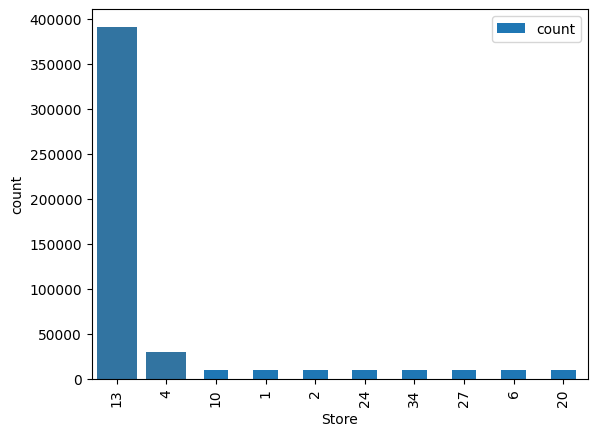

In [45]:
df['Store'].value_counts().head(10).plot(kind='bar')
sns.countplot(x='IsHoliday', data=df)


<Axes: >

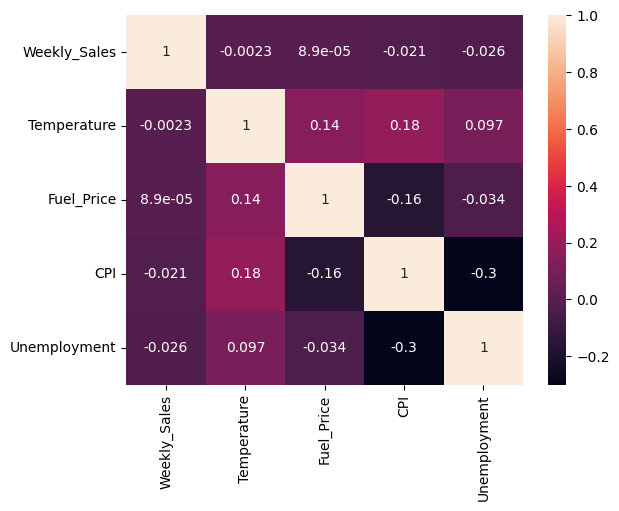

In [46]:
#sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
#sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)
sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(), annot=True)


In [47]:
df.drop(columns=['Date'],inplace=True)

C:\Users\mani\AppData\Local\Temp\ipykernel_1672\2008571477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Date'],inplace=True)


In [48]:
df.head(5)

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,Day
0,1,1,24924.50,42.31,2.572,211.096358,8.106,False,2010,2,5,5
1,1,1,46039.49,38.51,2.548,211.242170,8.106,True,2010,2,6,12
2,1,1,41595.55,39.93,2.514,211.289143,8.106,False,2010,2,7,19
3,1,1,19403.54,46.63,2.561,211.319643,8.106,False,2010,2,8,26
4,1,1,21827.90,46.50,2.625,211.350143,8.106,False,2010,3,9,5


In [49]:
df['Store'].nunique()

45

In [50]:
df['Dept'].nunique()

81

In [51]:
df['Year'].nunique()

3

In [52]:
yearly_sales = df.groupby('Year')['Weekly_Sales'].sum()

In [53]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

<Axes: xlabel='Year'>

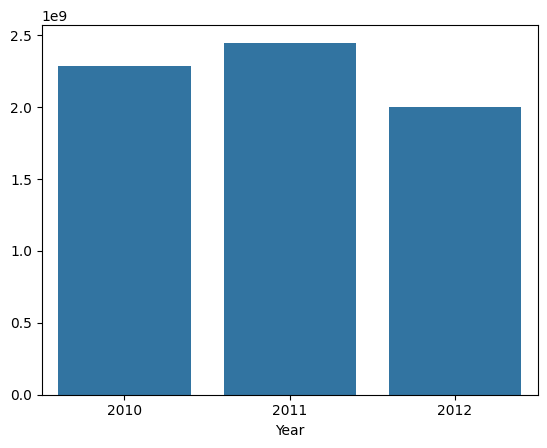

In [54]:
sns.barplot(x=yearly_sales.index,y=yearly_sales.values)

<Axes: xlabel='Month'>

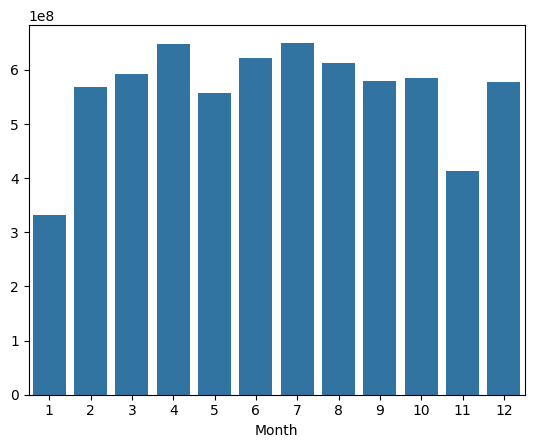

In [55]:
sns.barplot(x=monthly_sales.index,y=monthly_sales.values)

In [56]:
df.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [57]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

C:\Users\mani\AppData\Local\Temp\ipykernel_1672\390734960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IsHoliday'] = df['IsHoliday'].astype(int)


In [58]:
df['IsHoliday'].value_counts()

IsHoliday
0    390652
1     29560
Name: count, dtype: int64

In [59]:
df['IsHoliday'].value_counts()

IsHoliday
0    390652
1     29560
Name: count, dtype: int64

In [60]:
df.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [61]:
feature = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Day']
target = ['Weekly_Sales']       

In [62]:
X = df[feature]
y = df[target]

In [63]:
X

,Store,Dept,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,Day
0,1,1,42.31,2.572,211.096358,8.106,0,2010,2,5,5
1,1,1,38.51,2.548,211.242170,8.106,1,2010,2,6,12
2,1,1,39.93,2.514,211.289143,8.106,0,2010,2,7,19
3,1,1,46.63,2.561,211.319643,8.106,0,2010,2,8,26
4,1,1,46.50,2.625,211.350143,8.106,0,2010,3,9,5
...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,64.88,3.997,192.013558,8.684,0,2012,9,39,28
421566,45,98,64.89,3.985,192.170412,8.667,0,2012,10,40,5
421567,45,98,54.47,4.000,192.327265,8.667,0,2012,10,41,12
421568,45,98,56.47,3.969,192.330854,8.667,0,2012,10,42,19


In [64]:
y

,Weekly_Sales
0,24924.50
1,46039.49
2,41595.55
3,19403.54
4,21827.90
...,...
421565,508.37
421566,628.10
421567,1061.02
421568,760.01


In [65]:
X.shape

(420212, 11)

# Model Building

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
X_train.shape

(336169, 11)

In [68]:
X_test.shape

(84043, 11)

In [69]:
y_train.shape

(336169, 1)

In [70]:
y_test.shape

(84043, 1)

In [71]:
X.columns

Index(['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'IsHoliday', 'Year', 'Month', 'Week', 'Day'],
      dtype='object')

In [72]:
df['Day'].value_counts()

Day
2     14766
23    14760
9     14756
17    14746
6     14746
16    14729
13    14715
12    14709
10    14708
26    14707
25    14705
19    14702
24    14695
11    14692
30    14691
3     14690
5     14688
18    14685
20    14680
4     14644
27    14628
22    11741
7     11737
14    11732
8     11726
15    11724
28    11715
1     11710
29    11705
21    11703
31     5877
Name: count, dtype: int64

In [73]:
# cyclic transformations for day and month
# if we apply directly standard scaler
# then model think 31 and 1 or 12 and 1
# are far way so we first use sin and cos
# and then use standard scaler

X_train['Day_sin'] = np.sin(2 * np.pi * X_train['Day'] / 31)
X_train['Day_cos'] = np.cos(2 * np.pi * X_train['Day'] / 31)

X_test['Day_sin'] = np.sin(2 * np.pi * X_test['Day'] / 31)
X_test['Day_cos'] = np.cos(2 * np.pi * X_test['Day'] / 31)

X_train['Month_sin'] = np.sin(2 * np.pi * X_train['Month'] / 12)
X_train['Month_cos'] = np.cos(2 * np.pi * X_train['Month'] / 12)

X_test['Month_sin'] = np.sin(2 * np.pi * X_test['Month'] / 12)
X_test['Month_cos'] = np.cos(2 * np.pi * X_test['Month'] / 12)

# drop original month and day
X_train = X_train.drop(columns=['Day','Month'])
X_test = X_test.drop(columns=['Day','Month'])

In [74]:
X_train.columns

Index(['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'IsHoliday', 'Year', 'Week', 'Day_sin', 'Day_cos', 'Month_sin',
       'Month_cos'],
      dtype='object')

In [75]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Linear Regression

In [76]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
y_pred_linear_reg = linear_reg.predict(X_test)

In [78]:
def evaluate_metrics(y_pred,y_test=y_test):
    mae = mean_absolute_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)

    return mae,rmse,r2

In [79]:
def print_metrics(model,mae,rmse,r2):
    print(f"Evaluation Metrics of {model}")
    print(f"MAE : {mae}")
    print(f"RMSE : {rmse}")
    print(f"R2Score : {r2}")

In [80]:
mae_lg,rmse_lg,r2_lg = evaluate_metrics(y_pred_linear_reg)

In [81]:
print_metrics("Linear Regression",
mae_lg,rmse_lg,r2_lg)

Evaluation Metrics of Linear Regression
MAE : 15090.237083384369
RMSE : 22202.360736644532
R2Score : 0.03496592963535983


## Random Forest Regressor

In [82]:
random_forest_reg = RandomForestRegressor(n_estimators=1)
random_forest_reg.fit(X_train, y_train.values.ravel())

,n_estimators,1
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred_random_forest_reg = random_forest_reg.predict(X_test)

In [84]:
mae_rf,rmse_rf,r2_rf = evaluate_metrics(y_pred_random_forest_reg)

In [85]:
print_metrics(
    "RandomForest Regressor",
    mae_rf,rmse_rf,r2_rf
)

Evaluation Metrics of RandomForest Regressor
MAE : 2118.887653463108
RMSE : 5956.048301066026
R2Score : 0.9305518375503801


In [86]:
random_forest_reg.feature_importances_

array([0.27012385, 0.56959635, 0.01329959, 0.00597546, 0.06234472,
       0.02987848, 0.00070194, 0.00064311, 0.0235925 , 0.01443772,
       0.00340675, 0.00231915, 0.00368038])

In [87]:
columns = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'IsHoliday', 'Year', 'Week', 'Day_sin', 'Day_cos', 'Month_sin',
       'Month_cos']

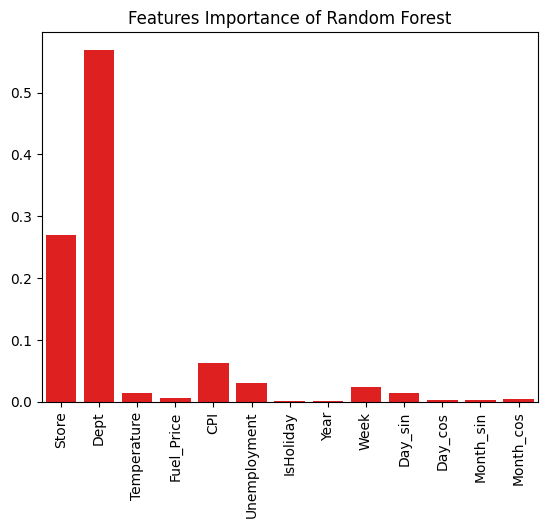

In [88]:

sns.barplot(x=columns,y=random_forest_reg.feature_importances_,
color="red")

plt.xticks(rotation=90)
plt.title("Features Importance of Random Forest")
plt.show()

In [89]:
random_forest_reg.n_features_in_

13

In [90]:
random_forest_reg.n_features_in_

13

## Light GBM

In [91]:
train_data_lightgbm = lgb.Dataset(
    X_train, label=y_train
)
test_data_lightgbm = lgb.Dataset(
    X_test, label= y_test, reference=train_data_lightgbm
)

In [92]:
params = {
    "objective":"regression",
    "boosting_type":"gbdt",
    "num_leaves": 31,
    "learning_rate": 0.1,
}
light_gbm = lgb.train(
    params,
    train_data_lightgbm,
    num_boost_round=1000,
    valid_sets=[train_data_lightgbm,test_data_lightgbm],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 336169, number of used features: 13
[LightGBM] [Info] Start training from score 16025.337168


In [93]:
y_pred_light_gbm = light_gbm.predict(X_test)

In [94]:
mae_lgbm,rmse_lgbm,r2_lgbm = evaluate_metrics(
    y_pred_light_gbm
)

In [95]:
print_metrics(
    "LightGBM",
    mae_lgbm,rmse_lgbm,r2_lgbm
)

Evaluation Metrics of LightGBM
MAE : 2585.771460245413
RMSE : 4422.425883379841
R2Score : 0.9617117547243882


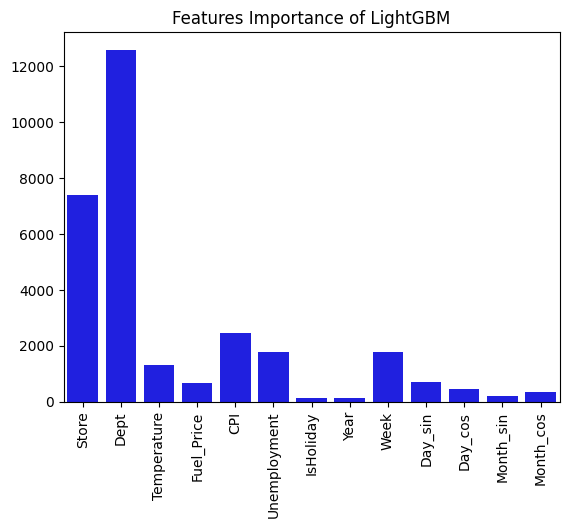

In [96]:

sns.barplot(x=columns,y=light_gbm.feature_importance(),
color="blue")

plt.xticks(rotation=90)
plt.title("Features Importance of LightGBM")
plt.show()

## XGBoost

In [97]:
xgboost = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgboost.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [98]:
y_pred_xgboost = xgboost.predict(X_test)

In [99]:
mae_xgb,rmse_xgb,r2_xgb = evaluate_metrics(
    y_pred_xgboost
)

In [100]:
print_metrics(
    "XGBoost",
    mae_xgb,rmse_xgb,r2_xgb
)

Evaluation Metrics of XGBoost
MAE : 5834.39111328125
RMSE : 9882.1494140625
R2Score : 0.8088179230690002


In [101]:
residuals_xgboost = y_test.values.ravel() - y_pred_xgboost 

In [102]:
residuals_random_forest = y_test.values.ravel() - y_pred_random_forest_reg

In [103]:
np.mean(residuals_xgboost)

np.float64(41.84581954504155)

In [104]:
np.mean(residuals_random_forest)

np.float64(-1.1546974762918842)

In [105]:
residuals_lgbm =  y_test.values.ravel() - y_pred_light_gbm

In [106]:
np.mean(residuals_lgbm)

np.float64(27.39350947391212)

In [112]:
print(f"Residuals standard deviation of  Random Forest : {np.std(residuals_random_forest)}")
print(f"Residuals standard deviation of LightGBM : {np.std(residuals_lgbm)}")
print(f"Residuals standard deviation of XGBoost : {np.std(residuals_xgboost)}")

Residuals standard deviation of  Random Forest : 5956.048189135582
Residuals standard deviation of LightGBM : 4422.341041759067
Residuals standard deviation of XGBoost : 9882.060860773827


In [107]:
print(y_test.shape)
print(y_pred_xgboost.shape)
type(y_pred_xgboost)

(84043, 1)
(84043,)


numpy.ndarray

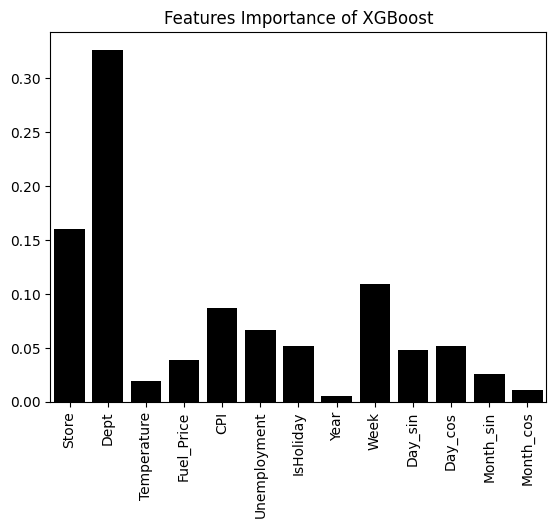

In [108]:

sns.barplot(x=columns,y=xgboost.feature_importances_,
color="black")

plt.xticks(rotation=90)
plt.title("Features Importance of XGBoost")
plt.show()

## 📊 Evaluation Metrics Comparison (R² in %)

| Model                   | MAE       | RMSE      | R² Score |
| ----------------------- | --------- | --------- | -------- |
| Linear Regression       | 15,090.24 | 22,202.36 | 3.50%    |
| Random Forest Regressor | 2,114.21  | 6,010.86  | 92.93%   |
| LightGBM                | 2,585.77  | 4,422.43  | 96.17%   |
| XGBoost                 | 5,834.39  | 9,882.15  | 80.88%   |


## 🧾 Residual Analysis Summary

| Model                       | Mean Residual   | Std. of Residuals | Direction                 | Interpretation                        |
| --------------------------- | --------------- | ----------------- | ------------------------- | ------------------------------------- |
| **Linear Regression**       | — *(not given)* | —                 | —                         | Likely large bias (poor fit)          |
| **Random Forest Regressor** | **–37.73**      | **5,956.05**      | 🔽 Overpredicts slightly  | Predictions a bit higher than actuals |
| **LightGBM**                | **+27.39**      | **4,422.34**      | 🔼 Underpredicts slightly | Predictions a bit lower than actuals  |
| **XGBoost**                 | **+41.00**      | **9,882.06**      | 🔼 Underpredicts slightly | Predictions slightly below actuals    |


## Conclusion


---

## 🏁 **Model Ranking Based on Residual Analysis**

🥇 **LightGBM** — Best overall performance with the lowest residual spread and near-zero bias.

🥈 **Random Forest Regressor** — Very good accuracy, slightly higher residual variance but still stable.

🥉 **XGBoost** — Accurate but shows more variability in predictions.

❌ **Linear Regression** — Performs poorly compared to the ensemble models, with large bias and error spread.

---

✅ **Summary:**
Ensemble models (LightGBM, Random Forest, and XGBoost) clearly outperform Linear Regression.
Among them, **LightGBM** provides the most balanced, stable, and reliable predictions.
